In [3]:
import matplotlib.pyplot as plt 
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
import sklearn.metrics as met

In [5]:
raw_data = pd.read_csv("GOODS1n.csv")
raw_data

,Class,Cost,Promotion,Before,After
0,Confection,23.99,1467,114957,122762
1,Drink,79.29,1745,123378,137097
2,Luxury,81.99,1426,135246,141172
3,Confection,74.18,1098,231389,244456
4,Confection,90.09,1968,235648,261940
...,...,...,...,...,...
195,Luxury,87.95,1206,208121,221053
196,Luxury,95.45,1678,224351,238264
197,Luxury,69.04,1926,264383,281239
198,Drink,104.56,1530,140021,157411


In [20]:
data_with_increase = raw_data.copy()
data_with_increase["Increase"] = (data_with_increase["After"] - data_with_increase["Before"])/data_with_increase["After"]*100
data_with_increase

,Class,Cost,Promotion,Before,After,Increase
0,Confection,23.99,1467,114957,122762,6.357831
1,Drink,79.29,1745,123378,137097,10.006784
2,Luxury,81.99,1426,135246,141172,4.197716
3,Confection,74.18,1098,231389,244456,5.345338
4,Confection,90.09,1968,235648,261940,10.037413
...,...,...,...,...,...,...
195,Luxury,87.95,1206,208121,221053,5.850181
196,Luxury,95.45,1678,224351,238264,5.839321
197,Luxury,69.04,1926,264383,281239,5.993479
198,Drink,104.56,1530,140021,157411,11.047513


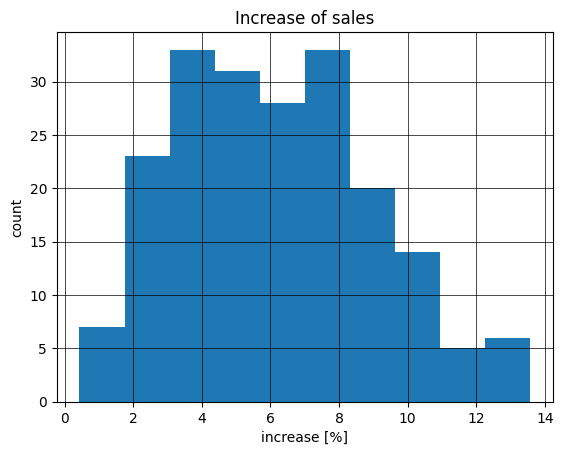

In [21]:
plt.hist(data_with_increase["Increase"])
plt.title("Increase of sales")
plt.xlabel("increase [%]")
plt.ylabel("count")
plt.grid(color="black", linewidth=.5)

In [28]:
def plot_graph(data, x_axis, y_axis, title):
    fig, ax = plt.subplots()
    color = {"Confection":"red", "Drink":"green", "Luxury":"blue", "Meat":"yellow"}
    grouped = data.groupby('Class')
    for key, group in grouped:
        group.plot(ax=ax, kind="scatter", x=x_axis, y=y_axis, label=key, color=color[key])
    plt.title(title)
    plt.show()

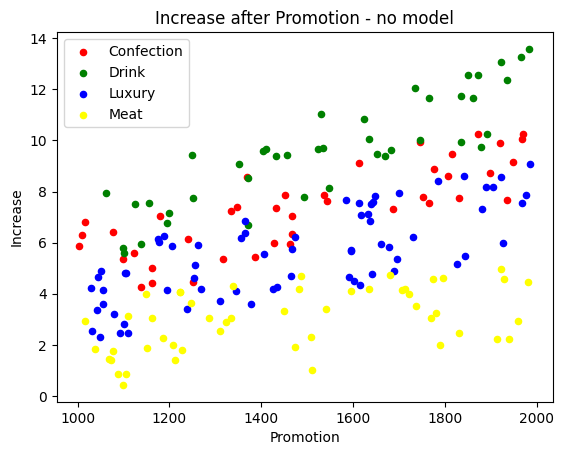

In [30]:
plot_graph(data_with_increase, "Promotion", "Increase", "Increase after Promotion - no model")

In [36]:
data_with_flags = data_with_increase.copy()
data_with_flags["Drink"] = [ 1 if n == "Drink" else 0 for n in data_with_flags["Class"]]
data_with_flags["Confection"] = [ 1 if n == "Confection" else 0 for n in data_with_flags["Class"]]
data_with_flags["Luxury"] = [ 1 if n == "Luxury" else 0 for n in data_with_flags["Class"]]
data_with_flags["Meat"] = [ 1 if n == "Meat" else 0 for n in data_with_flags["Class"]]
data_with_flags

,Class,Cost,Promotion,Before,After,Increase,Drink,Confection,Luxury,Meat
0,Confection,23.99,1467,114957,122762,6.357831,0,1,0,0
1,Drink,79.29,1745,123378,137097,10.006784,1,0,0,0
2,Luxury,81.99,1426,135246,141172,4.197716,0,0,1,0
3,Confection,74.18,1098,231389,244456,5.345338,0,1,0,0
4,Confection,90.09,1968,235648,261940,10.037413,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...
195,Luxury,87.95,1206,208121,221053,5.850181,0,0,1,0
196,Luxury,95.45,1678,224351,238264,5.839321,0,0,1,0
197,Luxury,69.04,1926,264383,281239,5.993479,0,0,1,0
198,Drink,104.56,1530,140021,157411,11.047513,1,0,0,0


In [39]:
data_with_interaction = data_with_flags.copy()
data_with_interaction["Drink_Interaction"] = data_with_interaction["Drink"] * data_with_interaction["Promotion"]
data_with_interaction["Confection_Interaction"] = data_with_interaction["Confection"] * data_with_interaction["Promotion"]
data_with_interaction["Luxury_Interaction"] = data_with_interaction["Luxury"] * data_with_interaction["Promotion"]
data_with_interaction["Meat_Interaction"] = data_with_interaction["Meat"] * data_with_interaction["Promotion"]
data_with_interaction

,Class,Cost,Promotion,Before,After,Increase,Drink,Confection,Luxury,Meat,Drink_Interaction,Confection_Interaction,Luxury_Interaction,Meat_Interaction
0,Confection,23.99,1467,114957,122762,6.357831,0,1,0,0,0,1467,0,0
1,Drink,79.29,1745,123378,137097,10.006784,1,0,0,0,1745,0,0,0
2,Luxury,81.99,1426,135246,141172,4.197716,0,0,1,0,0,0,1426,0
3,Confection,74.18,1098,231389,244456,5.345338,0,1,0,0,0,1098,0,0
4,Confection,90.09,1968,235648,261940,10.037413,0,1,0,0,0,1968,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,Luxury,87.95,1206,208121,221053,5.850181,0,0,1,0,0,0,1206,0
196,Luxury,95.45,1678,224351,238264,5.839321,0,0,1,0,0,0,1678,0
197,Luxury,69.04,1926,264383,281239,5.993479,0,0,1,0,0,0,1926,0
198,Drink,104.56,1530,140021,157411,11.047513,1,0,0,0,1530,0,0,0


In [41]:
input_var = data_with_interaction[["Promotion", "Drink", "Confection", "Luxury", "Meat", "Drink_Interaction", "Confection_Interaction", "Luxury_Interaction","Meat_Interaction" ]]
output_var = data_with_interaction[["Increase"]]

x_train, x_test, y_train, y_test = train_test_split(input_var, output_var, test_size=0.5, train_size=0.5)

In [48]:
linear_model = LinearRegression().fit(x_train, y_train)
y_pred = linear_model.predict(x_test)
y_pred = [n[0] for n in y_pred]

In [55]:
def print_analysis(y_test, y_pred):
    max_err = met.max_error(y_test, y_pred)
    mean_sq_err = met.mean_squared_error(y_test, y_pred)
    print("Max error:\t\t", max_err)
    print("Mean squared error: \t", mean_sq_err)

In [56]:
print_analysis(y_test, y_pred)

Max error:		 2.160766775482217
Mean squared error: 	 1.216757520318995
